# **Relatório — Laboratório 7**
## *Processamento Morfológico de Imagens* ##

## **Integrantes**
- Matheus Foresto Moselli
- Marcos Vinicius Medeiros da Silva
- Karl Eloy Marques Henrique

**Data do experimento:** 24/03/2026
**Data de publicação do relatório:** 07/04/2026

---

## **1. Introdução**
O processamento morfológico de imagens é uma ferramenta baseada na teoria dos conjuntos, utilizada para extrair componentes da imagem que são úteis na representação e descrição da forma de regiões. As operações fundamentais são a **Erosão** (que reduz objetos e remove detalhes finos) e a **Dilatação** (que expande objetos e preenche lacunas).

A partir dessas operações primárias, derivam-se a **Abertura** (erosão seguida de dilatação), eficaz para remover ruídos e pequenos objetos, e o **Fechamento** (dilatação seguida de erosão), ideal para fechar pequenos buracos e unir componentes próximos. Neste laboratório, exploramos a aplicação desses operadores em imagens binárias dos integrantes do grupo e imagens do projeto final, utilizando a biblioteca `morph.py`.

---

## **2. Procedimentos Experimentais**
Para a realização das atividades, foram seguidos os seguintes passos:

1.  **Configuração do Ambiente:** Importação das bibliotecas `OpenCV`, `NumPy`, `Matplotlib` e a biblioteca específica `morph.py` para operações morfológicas.
2.  **Preparação das Imagens:**
    - Leitura das imagens de grupo e do projeto final (detecção de comprimidos).
    - Conversão das imagens para escala de cinza via `mm.gray`.
    - **Binarização:** Aplicação de limiarização (`mm.threshold`) para converter as imagens em formato binário, requisito essencial para o processamento morfológico.
3.  **Aplicação dos Operadores:**
    - Utilização das funções `mm.erode`, `mm.dilate`, `mm.open` e `mm.close`.
    - Teste de diferentes tamanhos de **Elementos Estruturantes (Kernels)**, variando de 3x3 até 21x21, para observar o impacto da escala na filtragem.
4.  **Processamento do Projeto Final:** Implementação de uma função para extrair o gradiente morfológico e aplicar abertura/fechamento em imagens de interesse do projeto da equipe.


**2.1 - Exercícios realizados**

**3a)** Elabore um programa para realizar as operações de EROSÃO, DILATAÇÃO, ABERTURA, e FECHAMENTO, sobre as imagens em grupo dos integrantes da equipe bem como nos avatares, e apresente os resultados. Elabore uma análise detalhada de cada imagem, experimentado diversos tamanhos (3x3 até 21x21) de Elemento Estruturante – KERNEL - e compare-as entre si, quanto ao aspecto visual (filtragem, aparência, representação, etc) da
imagens resultantes. Lembre-se de binarizar as imagens antes da aplicação dos operadores. Assim, dentro desta análise, discuta se a binarização influiu no resultado e qual método foi mais interessante para sua aplicação.

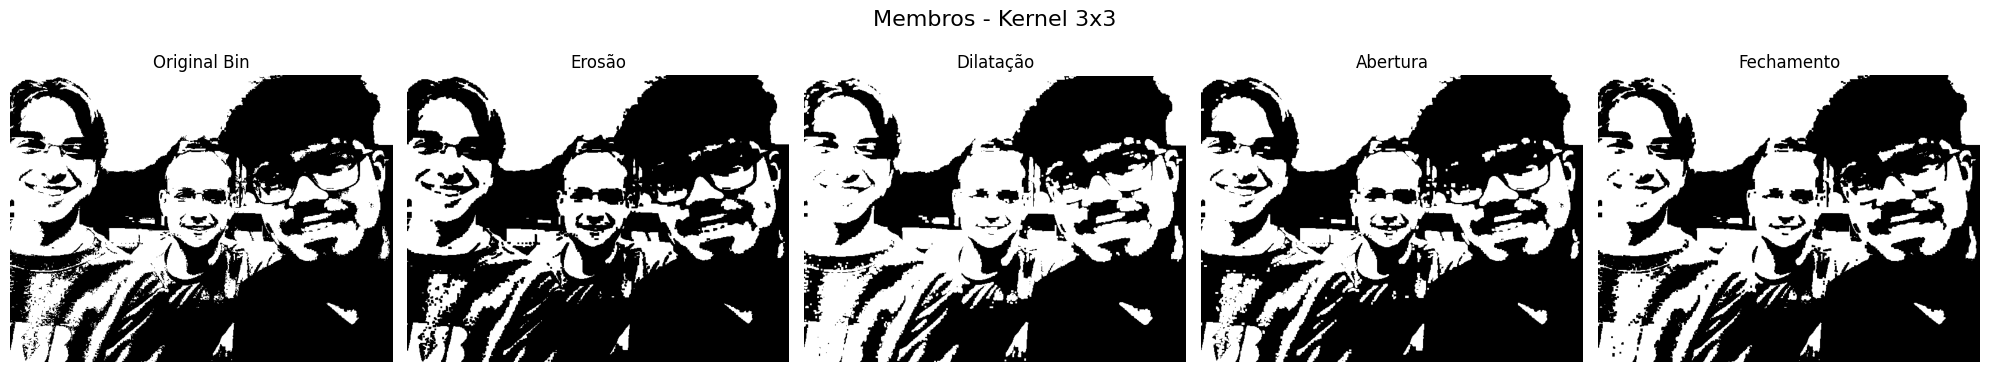

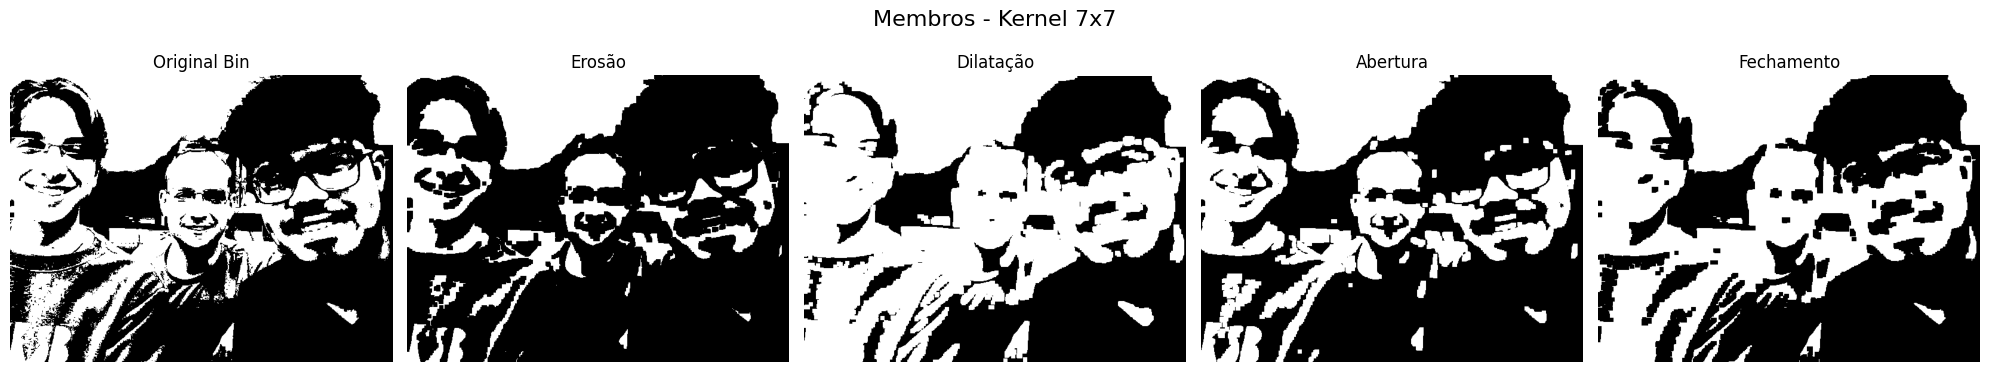

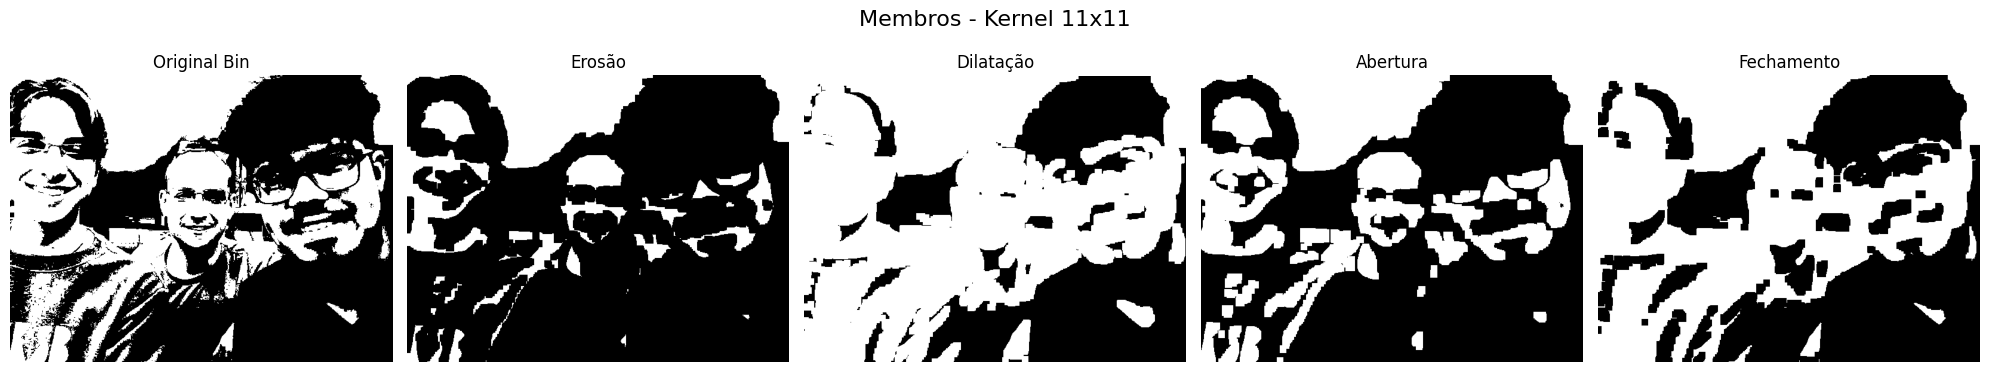

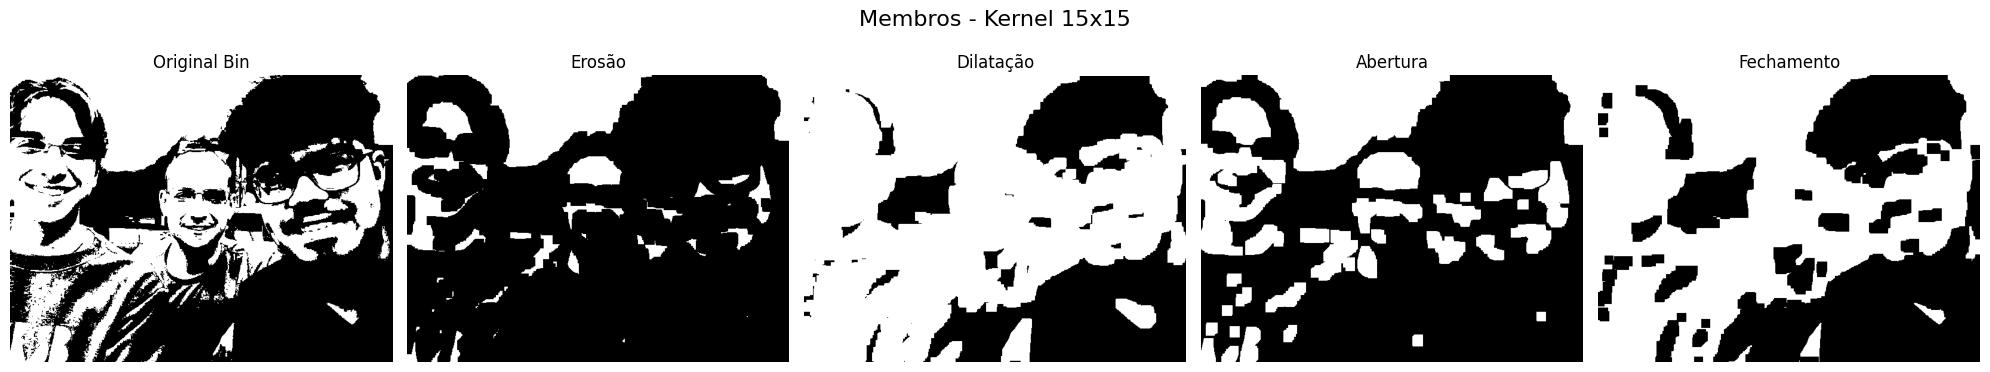

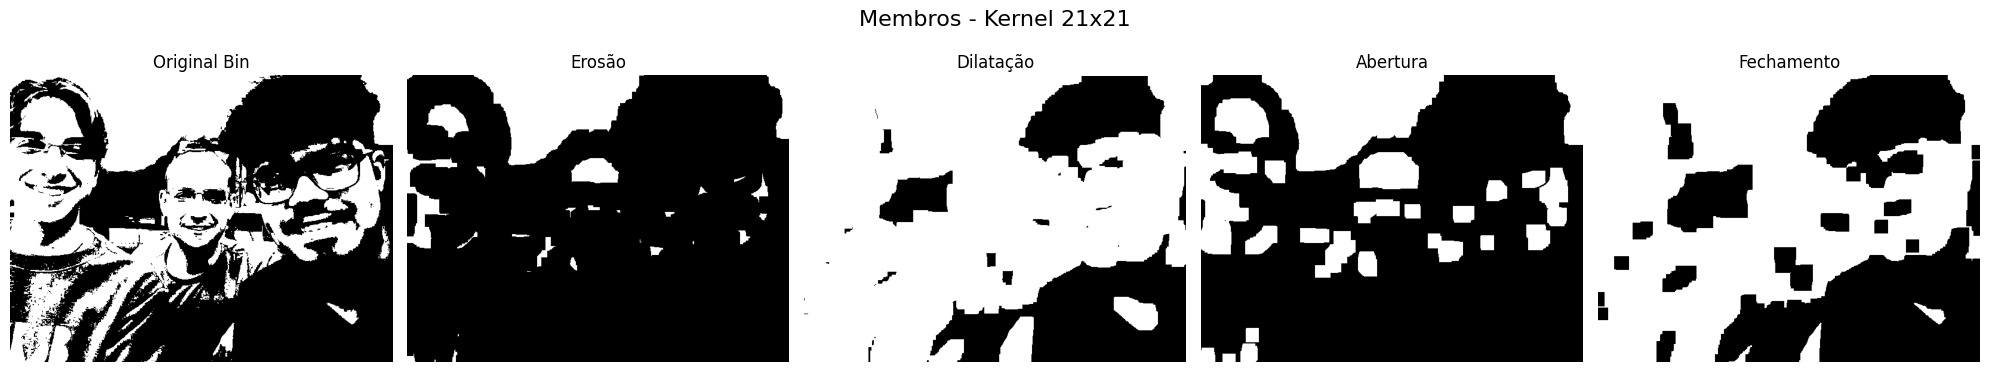

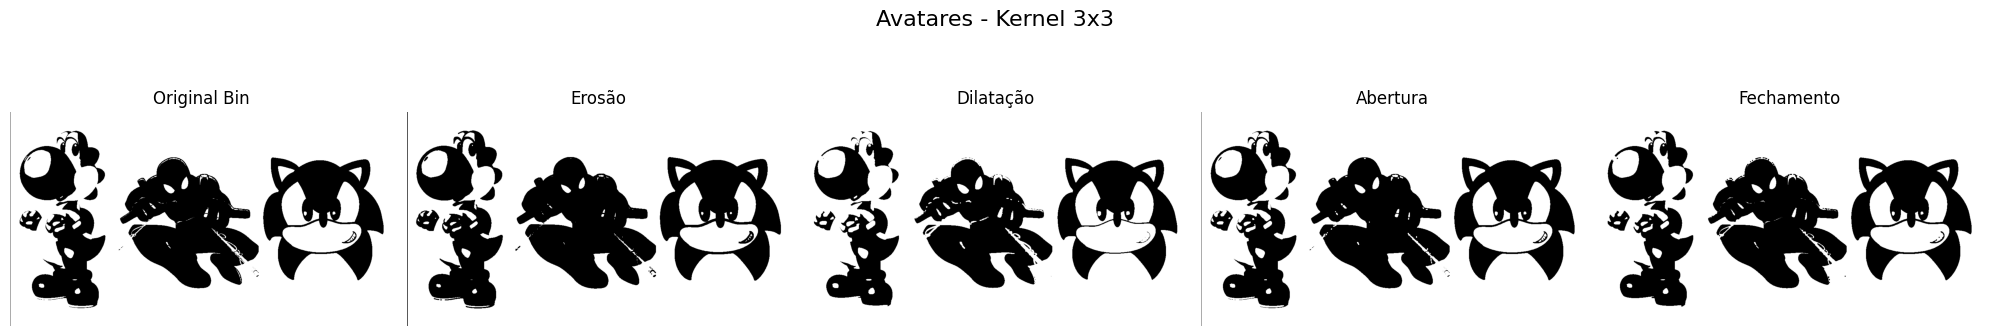

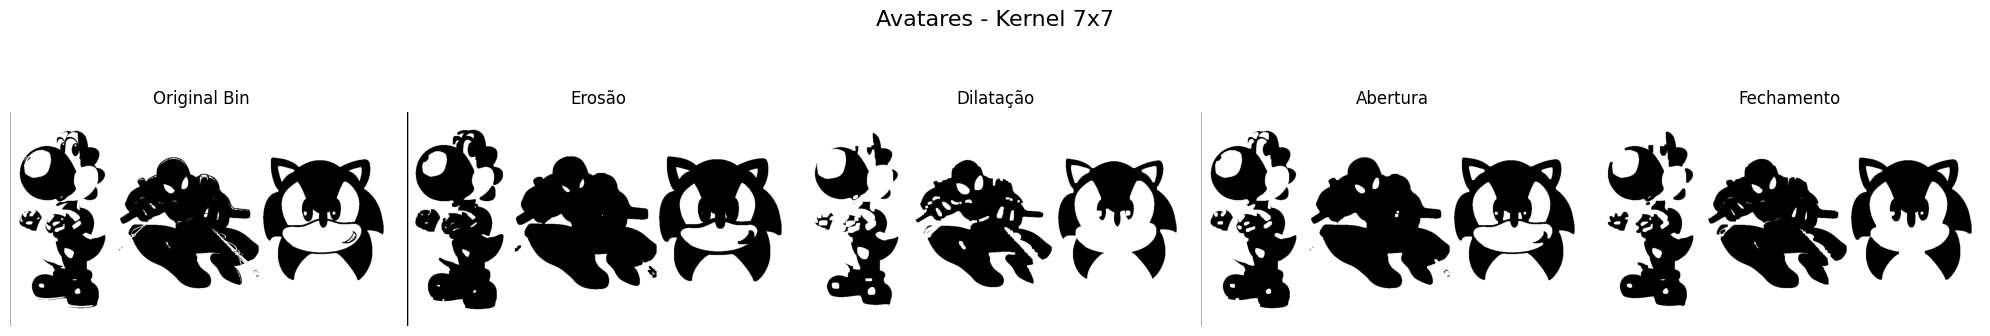

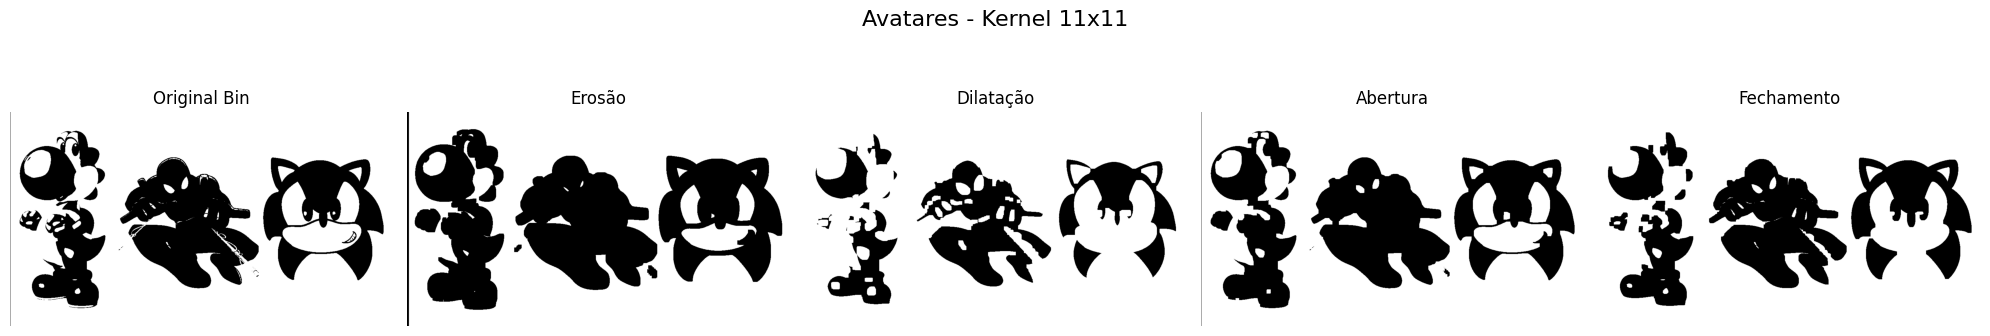

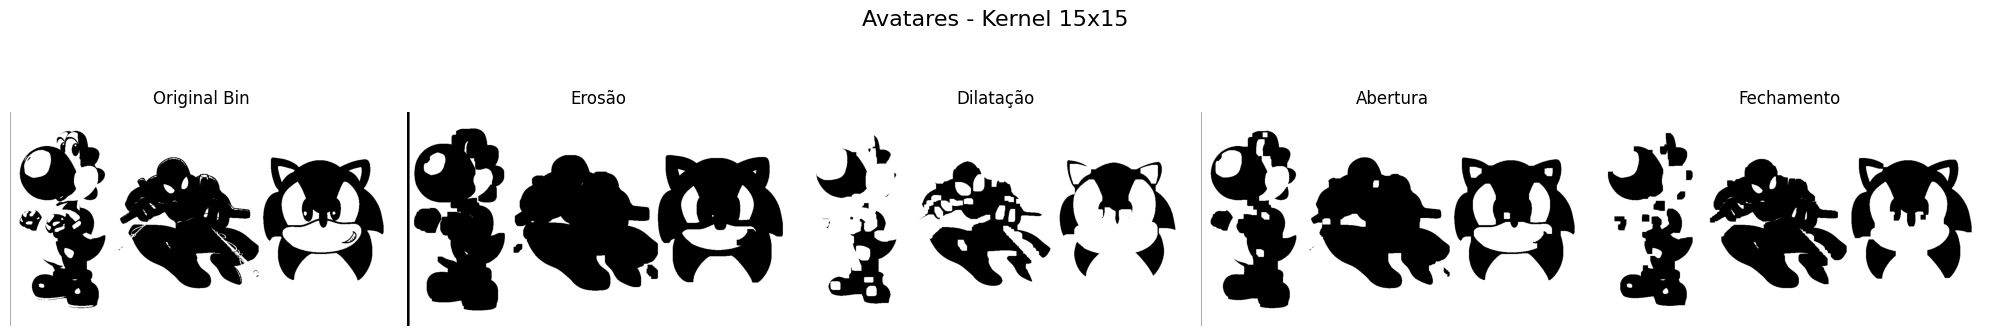

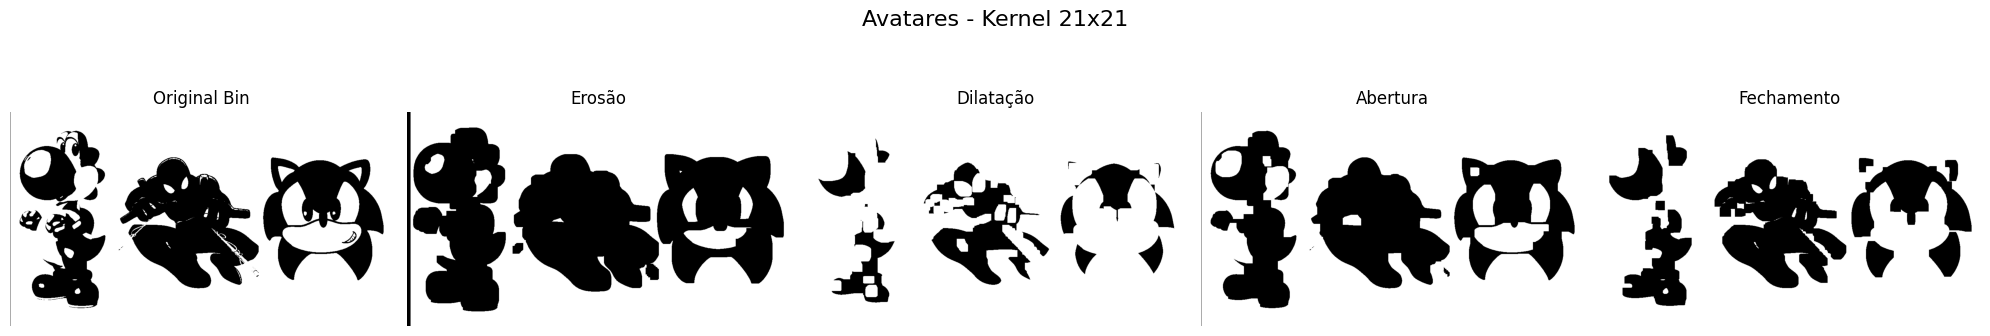

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from morph import *

mm.install()

## Ex 3a

img_membros = mm.read('images_grupo/alunos.png') 
img_avatares = mm.read('images_grupo/avatares.png')

def operacoes_edaf_com_variacao(img_input, titulo_prefixo):
    img_rgb = mm.color(img_input)
    img_gray = mm.gray(img_rgb)
    
    img_bin = mm.threshold(img_gray, 0)

    tamanhos_kernel = [3, 7, 11, 15, 21]
    
    for k_size in tamanhos_kernel:
        kernel = np.ones((k_size, k_size), np.uint8)
        
        operacoes = {
            "Erosão": mm.ero(img_bin, kernel),
            "Dilatação": mm.dil(img_bin, kernel),
            "Abertura": mm.open(img_bin, kernel),
            "Fechamento": mm.close(img_bin, kernel)
        }

        plt.figure(figsize=(20, 4))
        plt.suptitle(f"{titulo_prefixo} - Kernel {k_size}x{k_size}", fontsize=16)
        
        plt.subplot(1, 5, 1)
        plt.imshow(img_bin, cmap='gray')
        plt.title("Original Bin")
        plt.axis('off')

        for i, (nome, resultado) in enumerate(operacoes.items(), 2):
            plt.subplot(1, 5, i)
            plt.imshow(resultado, cmap='gray')
            plt.title(f"{nome}")
            plt.axis('off')
        
        plt.tight_layout()
        plt.show()

operacoes_edaf_com_variacao(img_membros, "Membros")
operacoes_edaf_com_variacao(img_avatares, "Avatares")

### **Erosão**
* **Aspecto Visual:** Atua reduzindo as áreas brancas (objetos).
* **Análise por Kernel:** No tamanho **3x3**, a erosão eliminou pixels isolados. Conforme o kernel aumentou para **21x21**, partes essenciais das silhuetas desapareceram, restando apenas o "núcleo" das formas mais densas.
* **Representação:** É eficaz para separar objetos que estão levemente encostados, mas torna-se destrutiva em kernels grandes.

### **Dilatação**
* **Aspecto Visual:** Expande as regiões brancas, preenchendo lacunas.
* **Análise por Kernel:** Em kernels pequenos, ajudou a solidificar as formas. Porém, a partir do **11x11**, os rostos dos membros da equipe e os corpos dos avatares começaram a se fundir. No **21x21**, a imagem virou uma massa branca contínua, perdendo a distinção individual.
* **Representação:** Útil para conectar partes de um objeto que foram separadas erroneamente na binarização.

### **Abertura (Erosão seguida de Dilatação)**
* **Aspecto Visual:** Remove pequenos objetos brancos e suaviza contornos.
* **Análise por Kernel:** Foi o operador de "limpeza" mais eficiente. Mesmo em kernels maiores (**15x15**), ele conseguiu remover texturas ruidosas do fundo sem alterar drasticamente o volume total dos alunos.
* **Representação:** Ideal para eliminar ruído tipo "sal" sem deformar o tamanho original dos objetos principais.

### **Fechamento (Dilatação seguida de Erosão)**
* **Aspecto Visual:** Fecha buracos pretos e canais dentro das formas brancas.
* **Análise por Kernel:** Nos **Avatares**, transformou desenhos com contornos em silhuetas sólidas (eliminando olhos e detalhes internos). Nos **Membros**, ajudou a unir falhas causadas por sombras ou reflexos nas roupas.
* **Representação:** Melhora a conectividade interna e a solidez da representação visual.



| Característica | Imagem "Membros" | Imagem "Avatares" |
| :--- | :--- | :--- |
| **Sensibilidade** | Alta. Kernels acima de 11x11 destruiram as feições dos integrantes do grupo. | Média. As formas são mais robustas e suportam kernels maiores. |
| **Melhor Kernel** | **3x3 ou 7x7**. Preservou a identidade visual. | **11x11**. Simplificou a imagem em silhuetas dos personagens. |
| **Filtragem** | A abertura limpou o ruído de fundo da foto. | O fechamento unificou os contornos dos personagens. |
---

É possível afirmar categoricamente que a binarização influenciou no resultado. Como a morfologia opera sobre lógica de pixels ligados/desligados, a qualidade da binarização define o que o kernel considera "objeto". Na imagem dos membros, o excesso de brilho em certas partes do cenário foi binarizado como branco, fazendo com que a dilatação unisse os alunos ao fundo indesejado.

Para fins de **limpeza e filtragem**, a **Abertura com Kernel 7x7** foi a mais interessante, pois removeu os ruídos granulados típicos de fotos reais sem causar a distorção severa vista nos kernels de 21x21. Para fins de **reconhecimento de formas**, o **Fechamento com Kernel 11x11** nos Avatares mostrou-se superior, gerando máscaras sólidas prontas para processamentos posteriores de visão computacional.

**3b)** Elabore um programa para realizar continuamente sobre a imagem da WEBCAM as
operações de Extração de Fronteiras (Gradiente Morfológico), mostrando na tela em tempo
real lado-a-lado a imagem original e a imagem extraída, permitindo ao operador escolher
– via teclado – a extração com diversos tamanhos de kernel. Grave um video demonstrativo
com os integrantes da equipe utilizando este programa com a webcam. Elabore uma
análise detalhada e explique os artefatos ocorridos.
Obs. O comando cv2.hconcat() une duas ou mais imagens horizontalmente (lado a lado),
desde que tenham a mesma altura. Ex.: resultado = cv2.hconcat([img1, img2])

In [ ]:
import cv2
import numpy as np
from morph import mm

cap = cv2.VideoCapture(0)
k_size = 3
gravando = False
out = None

while True:
    ret, frame = cap.read()
    if not ret:
        break

    img_rgb = mm.color(frame)
    img_gray = mm.gray(img_rgb)
    img_bin = mm.threshold(img_gray, 0)
    
    kernel = np.ones((k_size, k_size), np.uint8)
    fronteira = mm.gradm(img_bin, kernel)
    
    fronteira_bgr = cv2.cvtColor(fronteira, cv2.COLOR_GRAY2BGR)
    resultado = cv2.hconcat([frame, fronteira_bgr])
    
    cv2.putText(resultado, f"Kernel: {k_size}x{k_size}", (10, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    
    if gravando and out is not None:
        out.write(resultado)

    cv2.imshow('Lab7 - Gradiente Morfologico', resultado)

    key = cv2.waitKey(1) & 0xFF
    if key == ord('q'):
        break
    elif key == ord('s'):
        gravando = not gravando
        if gravando:
            h, w, _ = resultado.shape
            fourcc = cv2.VideoWriter_fourcc(*'XVID')
            out = cv2.VideoWriter('video_saida.avi', fourcc, 20.0, (w, h))
        else:
            out.release()
    elif key == ord('1'): k_size = 3
    elif key == ord('2'): k_size = 7
    elif key == ord('3'): k_size = 11
    elif key == ord('4'): k_size = 15
    elif key == ord('5'): k_size = 21

cap.release()
if out is not None:
    out.release()
cv2.destroyAllWindows()

Ao observar o vídeo demonstrativo com os integrantes Marcos e Matheus, nota-se uma diferenciação clara no vídeo capturado conforme o tamanho do Kernel aumenta:

### **Kernels Pequenos (3x3 a 5x5)**
* **Aspecto:** Bordas finas, precisas e detalhadas.
* **Comportamento:** Conseguiu captar detalhes sutis como o formato do cabelo e os aros dos óculos dos integrantes.

### **Kernels Médios (7x7 a 11x11)**
* **Aspecto:** As bordas tornam-se mais espessas e vibrantes.
* **Comportamento:** O sistema começa a ignorar detalhes muito pequenos e foca nas silhuetas principais dos integrantes.
Ocorre o fenômeno de **engrossamento de borda**. Áreas com texturas densas (como o cabelo cacheado) começam a se fundir, transformando-se em manchas brancas sólidas em vez de linhas individuais.

### **Kernels Grandes (15x15 a 21x21)**
* **Aspecto:** Bordas extremamente grossas, assemelhando-se a um efeito de "neon" ou "stencil" abstrato.
* **Comportamento:** Perda total da precisão geométrica. As fronteiras dos rostos tornam-se tão largas que o espaço entre os olhos e a boca pode ser preenchido completamente.
Aparecimento de **blocos quadrados**. Como o elemento estruturante utilizado é um kernel retangular/quadrado (`np.ones`), as bordas extraídas assumem um formato "pixelado" ou serrilhado, refletindo a geometria do próprio kernel em vez da anatomia real dos objetos.

**4a)** Elabore um programa para aplicar os operadores morfológicos imagens do seu
trabalho final, explicando o objetivo deste procedimento dentro do contexto da aplicação.

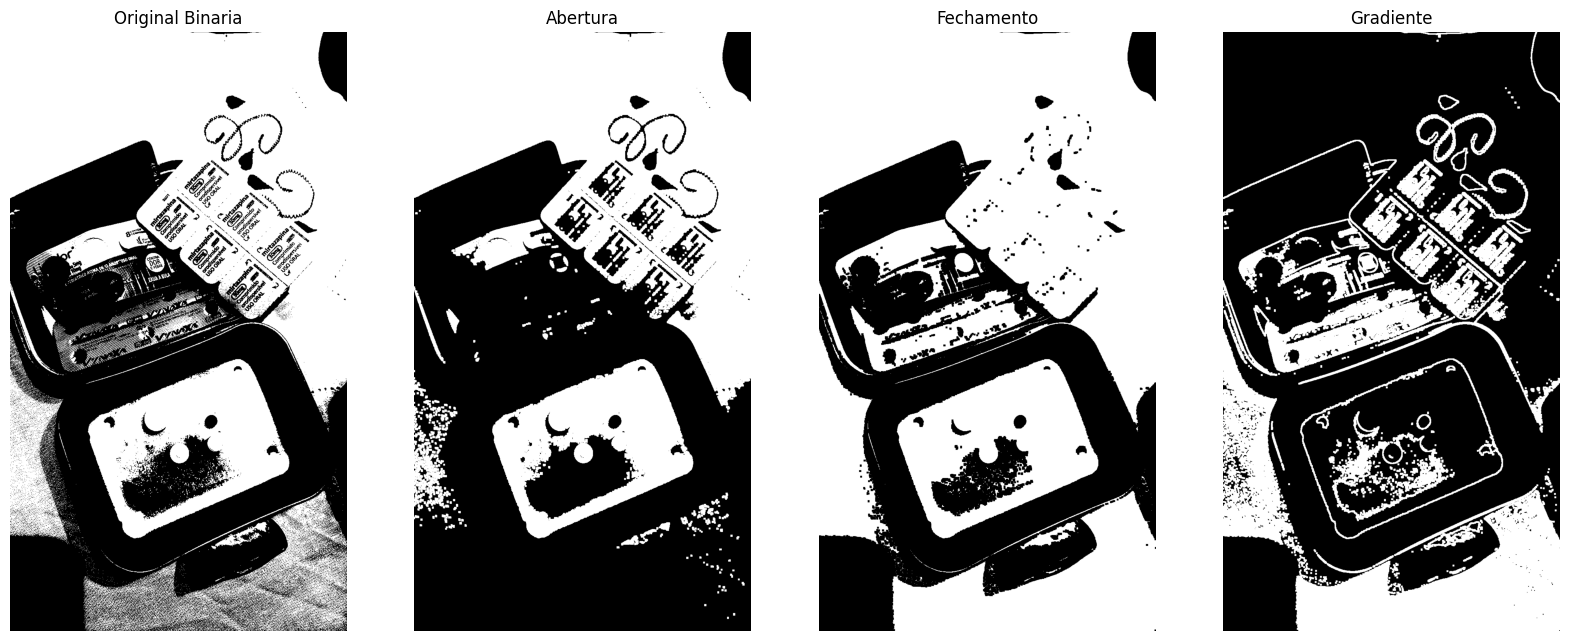

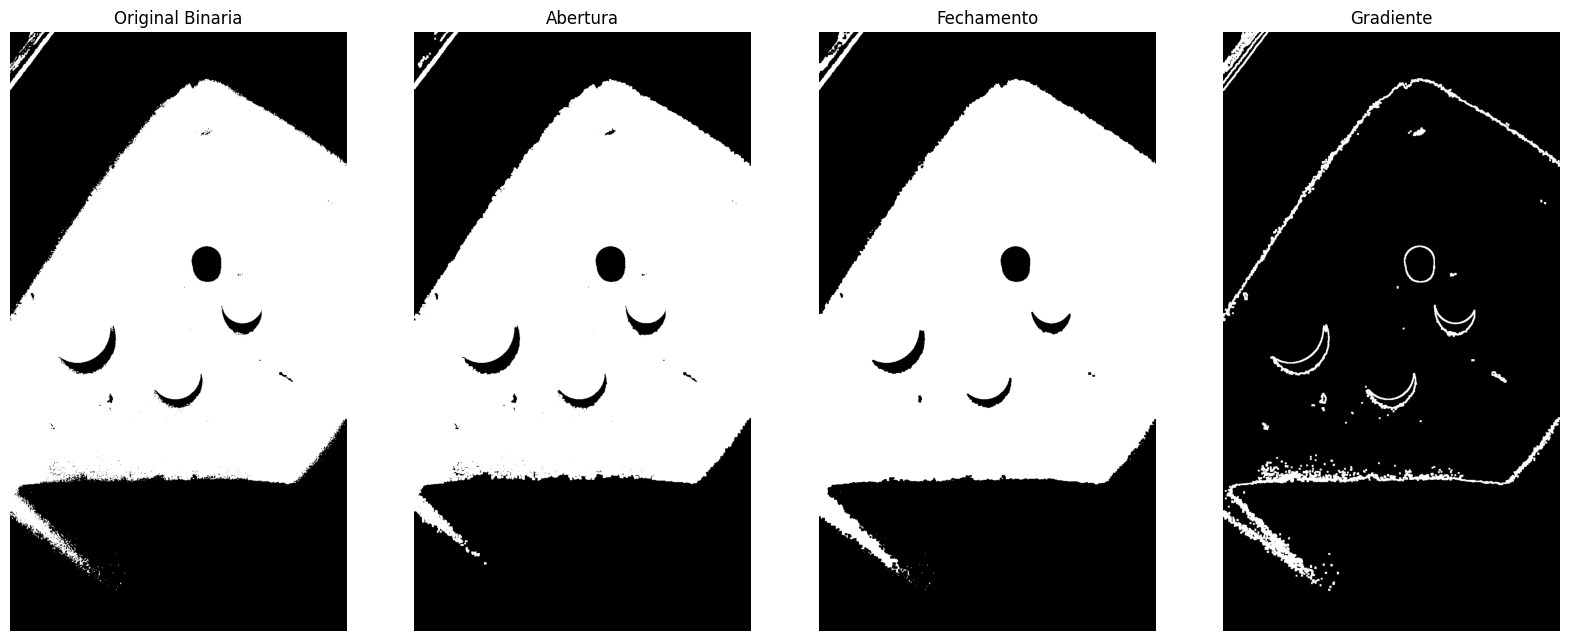

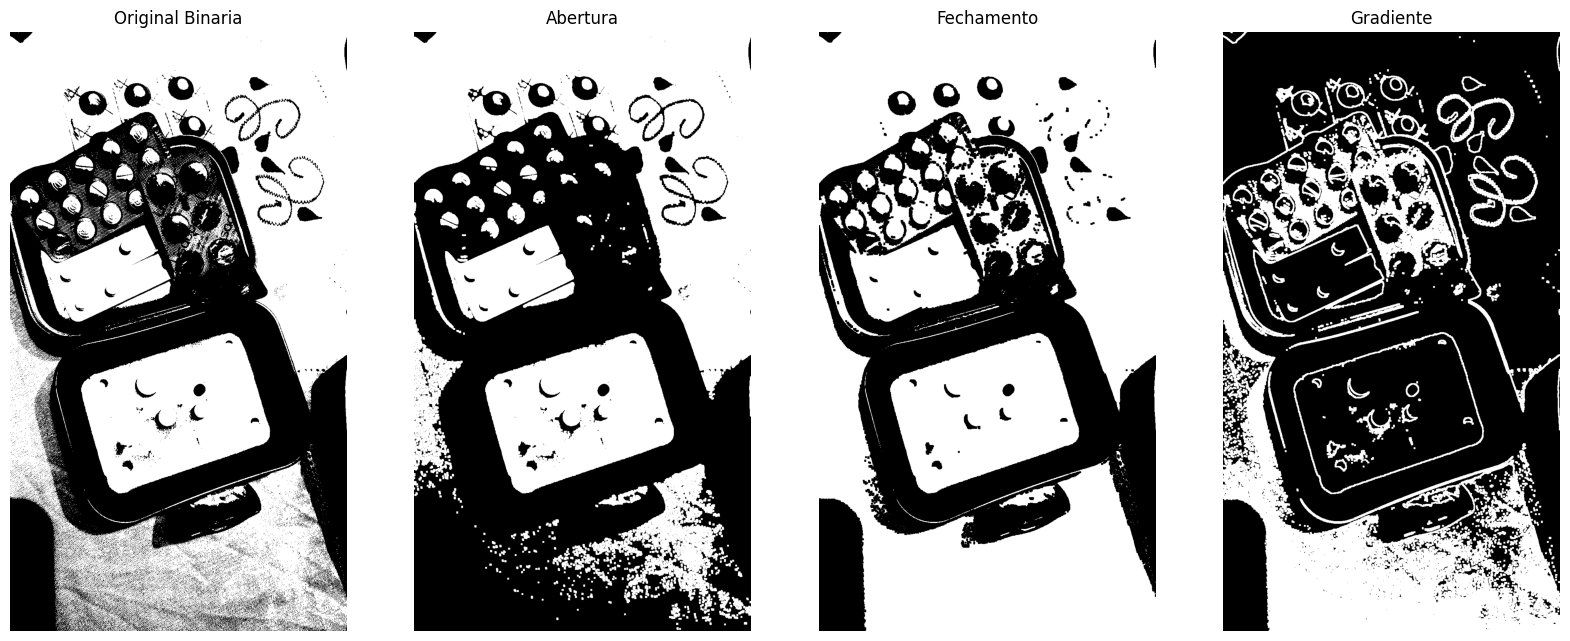

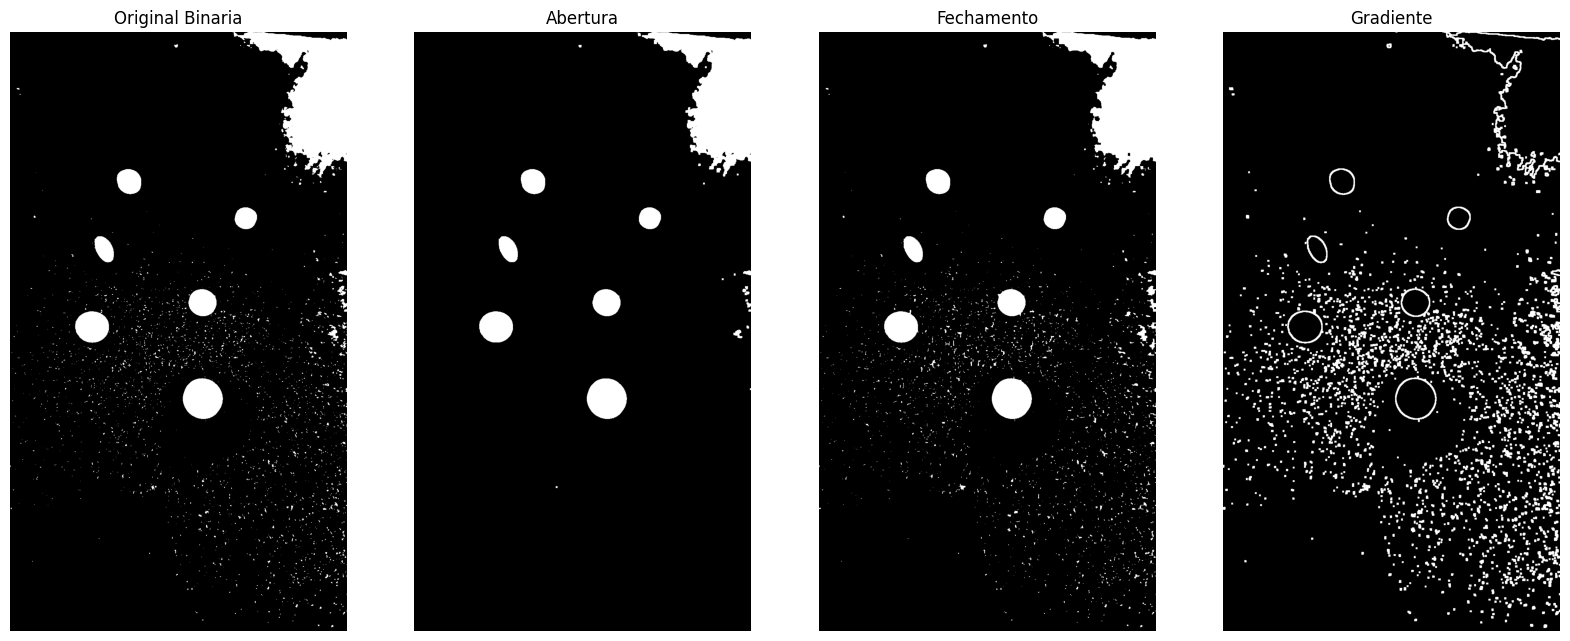

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from morph import mm
import os

def processar_projeto_final(img):
    img_rgb = mm.color(img)
    img_gray = mm.gray(img_rgb)
    img_bin = mm.threshold(img_gray, 0)

    kernel = np.ones((5,5), np.uint8)

    abertura = mm.open(img_bin, kernel)
    fechamento = mm.close(img_bin, kernel)
    gradiente = mm.gradm(img_bin, kernel)

    imagens = [img_bin, abertura, fechamento, gradiente]
    titulos = ['Original Binaria', 'Abertura', 'Fechamento', 'Gradiente']

    plt.figure(figsize=(20, 8))
    for i in range(4):
        plt.subplot(1, 4, i+1)
        plt.imshow(imagens[i], cmap='gray')
        plt.title(titulos[i])
        plt.axis('off')
    plt.show()

diretorio = 'images'
for arquivo in sorted(os.listdir(diretorio)):
    if arquivo.lower().endswith(('.jpeg', '.jpg', '.png')):
        img_projeto = mm.read(os.path.join(diretorio, arquivo))
        processar_projeto_final(img_projeto)

Ao aplicar os diferentes operadores morfológicos nas imagens do trabalho final, percebemos um detalhe interessante:
Na imagem *n4.png* (comprimidos sobre a mesa), todos os filtros cumpriram o objetivo principal que seria destacar os comprimidos, com destaque especial para o operador de abertura que separou com maestria os comprimidos dos ruidos da mesa. É possível afirmar que obtivemos um resultados misto para a imagem *n2.png* visto que houve separação dos comprimidos e fundo mas com algum grau de deformação. Os resultados para as imagens *n1.png* e *n3.png* não foram satisfatórios.

Ao utilizar os operadores, foi possível concluir que estabelecer uma restrição para a captura das imagens permitira um uso mais eficaz dos operadores morfológicos no contexto do nosso trabalho final, onde visamos detectar e classificar comprimidos.


---

## **3. Análise e Discussão**

Questões de Análise do Processamento Morfológico de imagens:
elabore as respostas para cada uma das questoes abaixo em forma de texto e/ou figuras, e apresente na parte de Análise e Discussão do relatório.

**5a)** Erosão e Estrutura: Ao aplicar uma erosão em uma imagem binária que contém
ruídos brancos (pontos isolados de 1 pixel) utilizando um kernel 3x3 de *uns*, o que
acontece com esses ruídos? Explique o porquê baseando-se no funcionamento do
operador.

**R:** Os ruídos brancos (pontos isolados de 1 pixel) desaparecem completamente da imagem. O operador de **Erosão** funciona como um teste de "encaixe". Para que o pixel central do kernel resulte em 1 (branco) na imagem de saída, **todos** os pixels da vizinhança cobertos pelo kernel (neste caso, 3x3) devem ser brancos na imagem original. Como o ruído é um ponto isolado cercado por pixels pretos (0), o kernel nunca encontrará um "encaixe perfeito", resultando na remoção do ponto.

**5b)** Dilatação e Conectividade: Suponha que você tenha uma imagem de um texto digitalizado onde as letras estão levemente "quebradas" ou fragmentadas. Qual o efeito de aplicar uma dilatação com um elemento estruturante pequeno (ex: 3x3)? Existe algum efeito colateral indesejado se o kernel for grande demais?

**R:** A dilatação irá expandir as bordas das letras fragmentadas. Esse "inchaço" controlado faz com que as partes quebradas se toquem e se fundam, restaurando a conectividade e a legibilidade dos caracteres. Se o kernel for excessivamente grande, ocorre a **coalescência indesejada**. As letras vizinhas (como o 'n' e o 'm', ou linhas de texto próximas) se fundem em blocos brancos sólidos, e os espaços internos (como o "buraco" da letra 'o' ou 'e') são completamente preenchidos, tornando o texto ilegível.

**5c)** Extração de Contornos (Gradiente): A extração de fronteira pode ser feita
subtraindo a imagem erosionada da imagem original (A−(A⊖B)) .
 -- Prática: O que mudaria no contorno resultante se aumentássemos o tamanho do
elemento estruturante B de 3x3 para 11x11? 

**R:** O contorno resultante ficaria muito mais largo.
* Com o kernel **3x3**, a erosão remove apenas uma fina camada da borda externa, resultando em um contorno de aproximadamente 1 pixel de largura.
* Com o kernel **11x11**, a erosão remove uma camada muito mais profunda da imagem original. Ao subtrair essa imagem "muito encolhida" da original, o resíduo (contorno) terá uma espessura proporcional ao raio do elemento estruturante.

**5d)**. Abertura vs. Fechamento:
* Qual dessas operações você utilizaria para remover pequenos objetos indesejados
(como poeira em um scan) sem alterar significativamente o tamanho dos objetos
principais?
* Qual você utilizaria para fechar pequenos buracos ou fendas dentro de um objeto
sólido?

**R:** Para remover poeira utilizaria a Abertura. Ela realiza uma erosão primeiro (que elimina a poeira por ser menor que o kernel) e depois uma dilatação (que recupera o tamanho original dos objetos grandes que restaram).
* Para fechar fendas/buracos (em objetos sólidos), utilizaria o Fechamento. Ele realiza uma dilatação primeiro (que preenche as fendas e buracos internos) e depois uma erosão (que devolve ao objeto o seu contorno externo original).

**5e)** Análise de Kernel (Geometria): No código da Parte 2, definimos kernels
retangulares, elípticos e em cruz.
*  Desafio Prático: Se você aplicar uma dilatação em um único pixel branco no centro
de uma imagem preta usando um “kernel_cross” (cruz), qual será o formato do objeto
resultante? E se usar o “kernel_rect”?

**R:**
* **Kernel_cross (Cruz):** O objeto resultante terá o formato de uma **cruz ou sinal de adição (+)**. A dilatação espalha o pixel central apenas nas direções cardeais (cima, baixo, esquerda, direita) definidas pela estrutura da cruz.
* **Kernel_rect (Retângulo/Quadrado):** O objeto resultante terá o formato de um **quadrado sólido**. Como todos os pixels do kernel 3x3 (ou superior) são 1, o pixel central se expande para preencher toda a vizinhança retangular coberta pelo elemento estruturante.

---

## **4. Conclusões**
Os experimentos demonstraram que o processamento morfológico é uma técnica robusta, especialmente quando aplicada às imagens binarizadas dos integrantes do grupo e do projeto de detecção de comprimidos. Verificou-se que a binarização é uma etapa crítica: um limiar mal ajustado impede que a erosão e a dilatação operem corretamente sobre as formas de interesse.

Em relação aos elementos estruturantes, o uso de kernels superiores a 11x11 nas fotos dos integrantes causou perda de características faciais essenciais, embora tenha sido ideal para suavizar o ruído de fundo. No contexto do projeto final, as operações de abertura mostraram-se fundamentais para isolar individualmente os comprimidos, confirmando que a escolha do operador e do tamanho do kernel deve ser estritamente guiada pela escala do detalhe que se deseja extrair ou filtrar

---

## **5. Referências**
- OPENCV. **Image Thresholding**. Disponível em: https://docs.opencv.org/3.4/d7/d4d/tutorial_py_thresholding.html. Acesso em: 3 abr. 2026.
- GONZALEZ, Rafael C.; WOODS, Richard E. **Digital Image Processing**. 4. ed. Pearson, 2018.
- MALLICK, Satya. **Image Thresholding using OpenCV**. Disponível em: https://learnopencv.com/opencv-threshold-python-cpp/. Acesso em: 5 abr. 2026.
